# Test Predictions

Kaggle has provided us with the test set, without the target variable. We will create the final submission file and upload it on Kaggle to get a score.

## Fit on the entire train set - X_train + X_val

In [1]:
import numpy as np
import pandas as pd

import joblib

In [2]:
# This is the file we saved in the Feature Engineering notebook
X_full_eng = pd.read_csv('data/X_full_eng.csv')
y_full = pd.read_csv('data/y_full.csv').squeeze()

In [3]:
# Drop zero importance features
zero_importance_features = joblib.load(
    'artifacts/zero_importance_features.joblib'
)

X_full_eng = X_full_eng.drop(
    columns=[f for f in zero_importance_features if f in X_full_eng.columns]
)

In [4]:
# We need the original dataset for uid creation
train_transaction = pd.read_csv("data/train_transaction.csv")
train_identity = pd.read_csv("data/train_identity.csv")

# Reconstruct full_set in the exact same order as X_full was created
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

val_size  = int(len(df) * 0.20)
train_set = (df.sort_values('TransactionDT', ascending=False)[val_size:]
               .sample(frac=1, random_state=42)
               .reset_index(drop=True))
val_set   = (df.sort_values('TransactionDT', ascending=False)[:val_size]
               .sample(frac=1, random_state=42)
               .reset_index(drop=True))

full_set = pd.concat([train_set, val_set], axis=0).reset_index(drop=True)

# Verify row count matches
print(f"full_set rows: {len(full_set)}")
print(f"X_full_eng rows: {len(X_full_eng)}")
assert len(full_set) == len(X_full_eng), "Row count mismatch — order will be wrong"

full_set rows: 590540
X_full_eng rows: 590540


In [5]:
# Create the uid on the full set
uid_full = (
    full_set['card1'].astype(str) + '_' +
    full_set['addr1'].astype(str) + '_' +
    full_set['P_emaildomain'].fillna('Missing').astype(str)
)

uid_agg_full = (
    full_set.assign(uid=uid_full)
    .groupby('uid')['TransactionAmt']
    .agg(['count', 'mean', 'std'])
    .rename(columns={
        'count': 'uid_txn_count',
        'mean':  'uid_amt_mean',
        'std':   'uid_amt_std'
    })
)

# UID for the engineered X file
X_full_eng['uid'] = uid_full.values
X_full_eng = X_full_eng.join(uid_agg_full, on='uid')

for col in ['uid_txn_count', 'uid_amt_mean', 'uid_amt_std']:
    X_full_eng[col] = X_full_eng[col].fillna(uid_agg_full[col].mean())

X_full_eng.drop(columns=['uid'], inplace=True)

# Save uid_agg_full for use on test set
uid_agg_full.to_csv('data/uid_agg_full.csv')

# While loading
# uid_agg_full = pd.read_csv('data/uid_agg_full.csv', index_col=0)

print(f"Final shape: {X_full_eng.shape}")

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_24928\1714665296.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_set.assign(uid=uid_full)
C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_24928\1714665296.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_full_eng['uid'] = uid_full.values


Final shape: (590540, 295)


## Transform Test Set

In [6]:
from lightgbm import LGBMClassifier

# Retrain final model on full engineered data
lgbm_final = joblib.load('models/lgbm_final.pkl')

lgbm_submission = LGBMClassifier(**lgbm_final.get_params())
lgbm_submission.fit(X_full_eng, y_full)

joblib.dump(lgbm_submission, 'models/lgbm_submission.pkl')
print("Submission model saved.")

Submission model saved.


In [7]:
# Transform test set using full pipeline
test_transaction = pd.read_csv('data/test_transaction.csv')
test_identity    = pd.read_csv('data/test_identity.csv')

test_df = test_transaction.merge(
    test_identity, on='TransactionID', how='left'
)

# Some columns in the test set are named with a dash instead of underscore
test_df.columns = test_df.columns.str.replace('-', '_', regex=False)

X_test = test_df.drop(columns=['TransactionID'])

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
import category_encoders as ce
from transformers import *

pipeline_full = joblib.load('models/feature_pipeline_full.pkl')

# Apply pipeline fitted on full data
X_test_eng = pipeline_full.transform(X_test)

print(f"X_test columns: {X_test.shape[1]}")
print(f"Any object columns remaining: {X_test.select_dtypes('object').columns.tolist()[:5]}")

# Drop zero importance features
X_test_eng = X_test_eng.drop(
    columns=[f for f in zero_importance_features if f in X_test_eng.columns]
)

# Add UID features using full train statistics
uid_test = (
    test_df['card1'].astype(str) + '_' +
    test_df['addr1'].astype(str) + '_' +
    test_df['P_emaildomain'].fillna('Missing').astype(str)
)

X_test_eng['uid'] = uid_test.values
X_test_eng = X_test_eng.join(uid_agg_full, on='uid')

for col in ['uid_txn_count', 'uid_amt_mean', 'uid_amt_std']:
    X_test_eng[col] = X_test_eng[col].fillna(uid_agg_full[col].mean())

X_test_eng.drop(columns=['uid'], inplace=True)

# Align columns to match training
X_test_eng = X_test_eng.reindex(
    columns=X_full_eng.columns, fill_value=0
)

print(f"Test shape:  {X_test_eng.shape}")
print(f"Train shape: {X_full_eng.shape}")
print(f"Match: {X_test_eng.shape[1] == X_full_eng.shape[1]}")

X_test columns: 432
Any object columns remaining: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']


C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_24928\552565909.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Any object columns remaining: {X_test.select_dtypes('object').columns.tolist()[:5]}")


Test shape:  (506691, 295)
Train shape: (590540, 295)
Match: True


## Final Predictions

In [9]:
# Predict and create submission
test_proba = lgbm_submission.predict_proba(X_test_eng)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_df['TransactionID'],
    'isFraud':       test_proba
})

submission.to_csv('data/submission.csv', index=False)

print(submission.head(10))
print(f"\nShape: {submission.shape}")
print(f"Probability range: {test_proba.min():.6f} – {test_proba.max():.6f}")
print(f"% flagged at 0.5 threshold: {(test_proba >= 0.5).mean()*100:.2f}%")

   TransactionID       isFraud
0        3663549  5.539803e-08
1        3663550  7.085757e-05
2        3663551  3.428686e-09
3        3663552  9.810009e-06
4        3663553  4.937746e-05
5        3663554  7.560559e-05
6        3663555  2.200928e-05
7        3663556  1.864695e-04
8        3663557  4.636405e-06
9        3663558  2.752421e-04

Shape: (506691, 2)
Probability range: 0.000000 – 1.000000
% flagged at 0.5 threshold: 2.27%


**Kaggle Submission:**

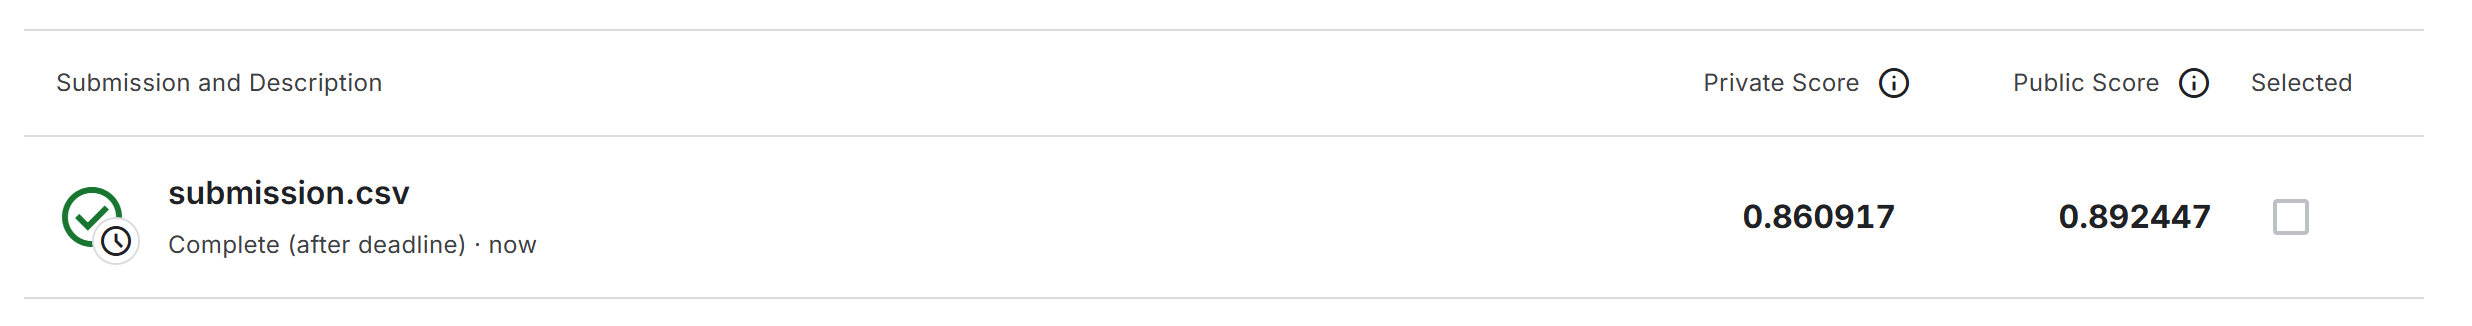